# Lab 3 - Intuicion estadistica Version 2


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Datos y particion 60/20/20

Se usa un conjunto sintetico de dos clases gaussianas para evaluar el clasificador SVC con kernel RBF.

In [2]:
def make_gaussian_dataset(means, covs, n_per_class, seed=42):
    rng = np.random.default_rng(seed)
    X_parts = []
    y_parts = []
    for label, (mean, cov) in enumerate(zip(means, covs)):
        samples = rng.multivariate_normal(mean, cov, size=n_per_class)
        labels = np.full(n_per_class, label)
        X_parts.append(samples)
        y_parts.append(labels)
    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y

def split_60_20_20(X, y, seed=42):
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.25, random_state=seed, stratify=y_trainval
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def build_svc(gamma, C=10.0):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=C, gamma=gamma))
    ])

def gamma_sweep(X_train, y_train, X_val, y_val, gammas, C=10.0):
    rows = []
    for gamma in gammas:
        model = build_svc(gamma=gamma, C=C)
        model.fit(X_train, y_train)
        rows.append({
            'gamma': gamma,
            'train_score': model.score(X_train, y_train),
            'val_score': model.score(X_val, y_val),
        })
    return pd.DataFrame(rows)

def plot_gamma_curve(results):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.semilogx(results['gamma'], results['train_score'], 'o-', label='Train score')
    ax.semilogx(results['gamma'], results['val_score'], 'o-', label='Validation score')
    ax.set_xlabel('gamma')
    ax.set_ylabel('accuracy')
    ax.set_title('Score vs gamma')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.show()

def plot_decision_boundary(model, X, y, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=30)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    return ax

means = [(0.0, 0.0), (2.4, 2.2)]
covs = [
    [[0.75, 0.15], [0.15, 0.70]],
    [[0.80, -0.10], [-0.10, 0.90]],
]

X, y = make_gaussian_dataset(means, covs, n_per_class=250, seed=42)
X_train, X_val, X_test, y_train, y_val, y_test = split_60_20_20(X, y, seed=42)

print('Shapes:')
print('  Train:', X_train.shape, y_train.shape)
print('  Val  :', X_val.shape, y_val.shape)
print('  Test :', X_test.shape, y_test.shape)

Shapes:
  Train: (300, 2) (300,)
  Val  : (100, 2) (100,)
  Test : (100, 2) (100,)


## 2. Curva del score en funcion de gamma

La mejor solucion se escoge con el score de validacion, no con el de test.

,gamma,train_score,val_score
0,0.001000,0.970000,0.93
1,0.002848,0.966667,0.92
2,0.008111,0.966667,0.92
3,0.023101,0.973333,0.93
4,0.065793,0.973333,0.93
5,0.187382,0.973333,0.93
6,0.533670,0.976667,0.93
7,1.519911,0.980000,0.93
8,4.328761,0.980000,0.93
9,12.328467,0.986667,0.91


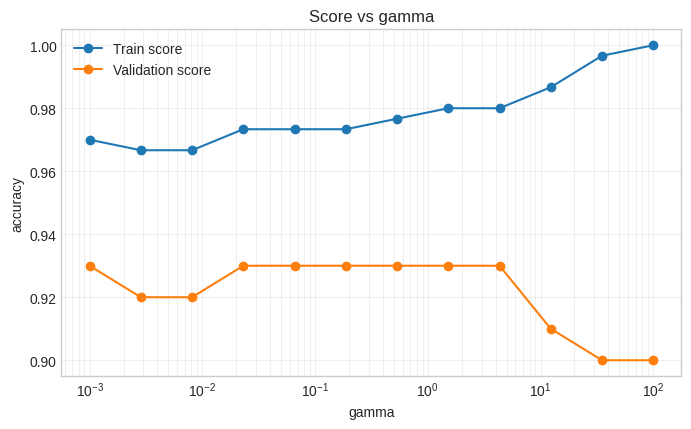

Best gamma: 0.001
Best train score: 0.9700
Best val score: 0.9300
Test score with best gamma: 0.9300


In [3]:
gammas = np.logspace(-3, 2, 12)
results = gamma_sweep(X_train, y_train, X_val, y_val, gammas, C=10.0)
results['gamma'] = results['gamma'].astype(float)
display(results)
plot_gamma_curve(results)

best_row = results.iloc[results['val_score'].idxmax()]
best_gamma = float(best_row['gamma'])
best_model = build_svc(gamma=best_gamma, C=10.0)
best_model.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))

print(f'Best gamma: {best_gamma:.6g}')
print(f'Best train score: {best_row["train_score"]:.4f}')
print(f'Best val score: {best_row["val_score"]:.4f}')
print(f'Test score with best gamma: {best_model.score(X_test, y_test):.4f}')

### Resultado esperado

- Gamma muy pequeno: frontera muy suave, tiende a subajustar.
- Gamma intermedio: mejor compromiso entre sesgo y varianza.
- Gamma muy grande: frontera muy flexible, tiende a sobreajustar.

## 3. Curvas de aprendizaje

Se construyen usando el mejor modelo obtenido en la busqueda de gamma.

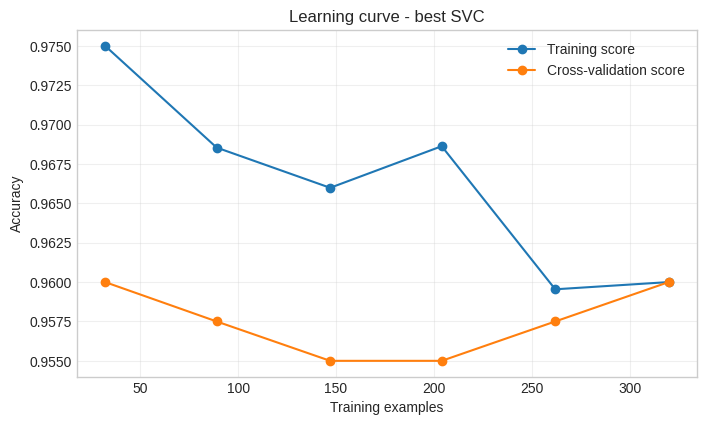

In [4]:
def plot_learning_curve(estimator, X, y, title, cv=5, n_jobs=1, train_sizes=np.linspace(0.1, 1.0, 6)):
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv_strategy, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy'
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(sizes, train_mean, 'o-', label='Training score')
    ax.plot(sizes, val_mean, 'o-', label='Cross-validation score')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
plot_learning_curve(best_model, X_trainval, y_trainval, 'Learning curve - best SVC')

### Interpretacion

Si la curva de entrenamiento y la de validacion se acercan al crecer el numero de ejemplos, el modelo generaliza mejor. Si la separacion entre ambas es grande, hay sobreajuste. Si ambas se quedan bajas, hay subajuste.

## 4. Ejemplos de overfitting y underfitting

Se evalua el mismo modelo optimo anterior sobre dos nuevas configuraciones de medias y covarianzas para ilustrar el efecto del cambio en la distribucion.

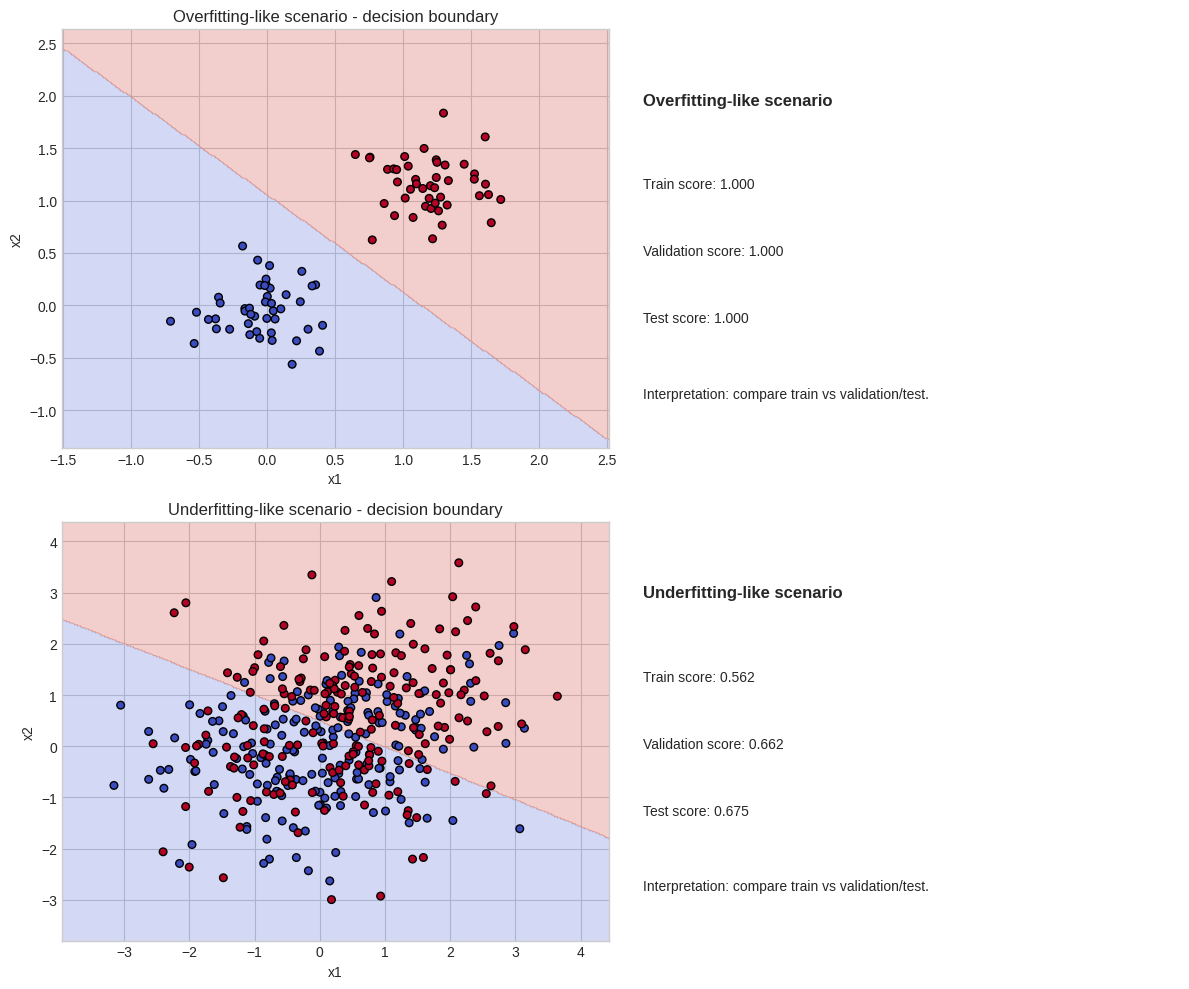

In [5]:
scenario_specs = {
    'Overfitting-like scenario': {
        'means': [(0.0, 0.0), (1.25, 1.20)],
        'covs': [
            [[0.08, 0.00], [0.00, 0.08]],
            [[0.08, 0.00], [0.00, 0.08]],
        ],
        'n_per_class': 45,
        'seed': 7,
    },
    'Underfitting-like scenario': {
        'means': [(0.0, 0.0), (0.60, 0.55)],
        'covs': [
            [[1.60, 0.35], [0.35, 1.40]],
            [[1.50, 0.30], [0.30, 1.50]],
        ],
        'n_per_class': 200,
        'seed': 21,
    },
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (title, spec) in enumerate(scenario_specs.items()):
    X_s, y_s = make_gaussian_dataset(
        spec['means'], spec['covs'], spec['n_per_class'], seed=spec['seed']
    )
    scenario_model = build_svc(gamma=best_gamma, C=10.0)
    scenario_model.fit(X_s, y_s)
    train_score = scenario_model.score(X_s, y_s)
    axes[2 * idx].set_title(f'{title} | score={train_score:.3f}')
    plot_decision_boundary(scenario_model, X_s, y_s, f'{title} - decision boundary', ax=axes[2 * idx])

    X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = split_60_20_20(X_s, y_s, seed=spec['seed'])
    model_split = build_svc(gamma=best_gamma, C=10.0)
    model_split.fit(X_train_s, y_train_s)
    axes[2 * idx + 1].axis('off')
    axes[2 * idx + 1].text(0.02, 0.82, title, fontsize=12, weight='bold')
    axes[2 * idx + 1].text(0.02, 0.62, f'Train score: {model_split.score(X_train_s, y_train_s):.3f}')
    axes[2 * idx + 1].text(0.02, 0.46, f'Validation score: {model_split.score(X_val_s, y_val_s):.3f}')
    axes[2 * idx + 1].text(0.02, 0.30, f'Test score: {model_split.score(X_test_s, y_test_s):.3f}')
    axes[2 * idx + 1].text(0.02, 0.12, 'Interpretation: compare train vs validation/test.')

plt.tight_layout()
plt.show()

## Conclusiones

- La mejor solucion se elige con el score de validacion, no con el de test.
- Gamma pequeno produce fronteras demasiado suaves y suele subajustar.
- Gamma grande produce fronteras muy flexibles y puede sobreajustar.
- En las curvas de aprendizaje, una brecha grande entre entrenamiento y validacion sugiere sobreajuste; si ambas curvas quedan bajas, hay subajuste.